# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MohinaRustamova/lyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

**Research question:** Which content pages should be reviewed first for refresh,
given limited reviewer capacity?

**Lane:** Refresh / Content Opportunity Scoring.

**Decision this supports:** without a ranked queue, a reviewer finds refresh
candidates by manual browsing or ad hoc judgment. This ranks the full inventory
so limited review time goes to the pages most worth a look first.

**Who acts on it:** a content reviewer or SEO strategist, working through the
top of the ranked queue each review cycle, guided by reason codes.

**Cost of a wrong call:** flagging a page that wasn't really declining wastes a
reviewer's time on a false alarm. Missing a page that was genuinely declining
means real visibility loss goes unreviewed until the next cycle. Neither cost is
catastrophic on its own, which is why this is built as decision-support, not an
automated action, a human checks every recommendation before anything happens
to a page.

In [1]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
print("Label used throughout: is_declining_label")
print("Definition: 1 if a page's current-30-day GSC impressions are more than")
print("20% below its prior-30-day impressions, else 0")
print("Decision date used across all modeling: 2026-03-31")

Label used throughout: is_declining_label
Definition: 1 if a page's current-30-day GSC impressions are more than
20% below its prior-30-day impressions, else 0
Decision date used across all modeling: 2026-03-31


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

**Two datasets were used, at two different stages, and this paper is explicit about
which numbers come from which.**

**Early exploration (Week 1-2):** the anonymized starter slice shipped in the repo,
`content_refresh_anonymized.csv`, 30,000 rows across 32 pseudonymized clients, a
90-day trailing window, label derived from `trend_direction`. Used only to validate
the workflow (baseline rule vs. a simple model, Precision@K) before committing to a
lane. These numbers (54.2% decline share, baseline Precision@50 = 0.240, random
forest Precision@50 = 0.740) are not the paper's final results, they're early
scoping evidence.

**Final modeling (Week 5 onward):** the full FlyRank internship warehouse release
on Hugging Face (`FlyRank/internship-warehouse`), export date 2026-07-03, gated
access. Two tables: `fact_content_daily_performance` (daily GSC/GA4 facts) and
`dim_content` (content properties). Freshness lag: the freshest 3 days were cut at
export, so daily facts stop at 2026-06-30.

**Windows used:** prior-30-day window (2026-01-31 to 2026-03-01) and current-30-day
window (2026-03-02 to 2026-03-31), decision date 2026-03-31. All features are
computed strictly before this date.

**Filters applied:** joined on client_hash_id and content_hash_id, restricted to
rows with gsc_data_available = TRUE and impressions_prior30 > 0 (a page needs a
prior baseline to have a defined percent-change label). Content restricted to
is_published = TRUE and is_deleted = FALSE. After these filters, 135,113 content
rows across 42 clients remained, of which 29 clients were used for training and 13
held out for validation.

**What was excluded and why:** no client names, domains, URLs, or raw search
queries are used anywhere, all identifiers are pseudonymized hashes present in the
release itself. Optimization-history features (has_been_optimized,
days_since_last_optimized) exist in the schema but carry no signal at this decision
date, no optimization in the warehouse predates 2026-03-31 (confirmed in w05/w06).
FlyRank product flags (health score, provider_used, model_used) were excluded from
modeling entirely, per the lane's leakage rules, they encode an existing system's
decisions, not observable ground truth.

In [2]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# ---- Setup: pull the real warehouse data and confirm the Data section's numbers live ----
import os, sys, subprocess
IN_COLAB = "google.colab" in sys.modules
REPO_URL, REPO_DIR = "https://github.com/MohinaRustamova/flyrank-ml-internship", "flyrank-ml-internship"
if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)

%pip -q install duckdb

import duckdb
import pandas as pd
import numpy as np

con = duckdb.connect()

if IN_COLAB:
    from google.colab import userdata
    HF_TOKEN = userdata.get("HF_TOKEN")
else:
    from getpass import getpass
    HF_TOKEN = getpass("HF_TOKEN: ")

con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

FACT = "read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/**/*.parquet')"
DIMC = "read_parquet('hf://datasets/FlyRank/internship-warehouse/dim_content.parquet')"
DECISION_DATE = "2026-03-31"

# Rebuild the actual filtered dataset, same joins/filters as w05 onward
feature_frame = con.sql(f"""
    WITH prior AS (
        SELECT client_hash_id, content_hash_id,
               SUM(gsc_impressions) AS impressions_prior30
        FROM {FACT}
        WHERE report_date BETWEEN DATE '2026-01-31' AND DATE '2026-03-01'
          AND gsc_data_available IS TRUE
        GROUP BY client_hash_id, content_hash_id
    ),
    current AS (
        SELECT client_hash_id, content_hash_id,
               SUM(gsc_impressions) AS impressions_current30
        FROM {FACT}
        WHERE report_date BETWEEN DATE '2026-03-02' AND DATE '2026-03-31'
          AND gsc_data_available IS TRUE
        GROUP BY client_hash_id, content_hash_id
    )
    SELECT p.client_hash_id, p.content_hash_id,
           CASE WHEN c.impressions_current30 < p.impressions_prior30 * 0.8
                THEN 1 ELSE 0 END AS is_declining_label
    FROM prior p
    JOIN current c USING (client_hash_id, content_hash_id)
    WHERE p.impressions_prior30 > 0
""").df()

print("=== Full warehouse (final modeling), live-confirmed ===")
print(f"Rows after filters: {len(feature_frame):,}")
print(f"Distinct clients: {feature_frame['client_hash_id'].nunique()}")
print(f"Base rate (is_declining_label): {feature_frame['is_declining_label'].mean():.3f}")

print("\n=== Starter slice (early exploration, w01, not re-pulled here) ===")
print("Rows: 30,000 | Clients: 32 | Decline share: 54.2%")
print("Baseline Precision@50: 0.240 | Random Forest Precision@50: 0.740 | Lift: 3.1x")
print("(This slice isn't reloaded here since it's cited only as early scoping context,")
print(" not part of the paper's final results, which come entirely from the warehouse.)")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

=== Full warehouse (final modeling), live-confirmed ===
Rows after filters: 135,113
Distinct clients: 42
Base rate (is_declining_label): 0.240

=== Starter slice (early exploration, w01, not re-pulled here) ===
Rows: 30,000 | Clients: 32 | Decline share: 54.2%
Baseline Precision@50: 0.240 | Random Forest Precision@50: 0.740 | Lift: 3.1x
(This slice isn't reloaded here since it's cited only as early scoping context,
 not part of the paper's final results, which come entirely from the warehouse.)


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

**Label:** is_declining_label = 1 if a page's current-30-day GSC impressions are more
than 20% below its prior-30-day impressions, else 0. A same-portfolio, same-metric
comparison, not a claim about search-algorithm behavior.

**Features (12, all knowable strictly before the decision date):**
prior-30-day performance (impressions, clicks, CTR, average position), content_age_days,
days_since_last_optimized and has_been_optimized (filtered to exclude any optimization
after the decision date), word_count and has_word_count, and one-hot content type
(comparison article / feedly article / keyword article).

**Excluded by design:** FlyRank product flags (health score, provider_used,
model_used) — using an existing system's output as a feature means learning that
system's old decisions, not the underlying world (per the lane's leakage rules).
Also excluded: any column computed from the current-30-day window, since that
window is what defines the label itself.

**Assumptions:** a 20% impression drop is a meaningful decline signal, not noise or
normal week-to-week variance; 30-day windows are long enough to smooth daily
fluctuation while staying close enough to the decision date to be actionable; a
page needs a nonzero prior-30-day impression baseline for a percent-change label to
be defined, so zero-prior-impression pages are excluded rather than assigned an
undefined label.

**Baseline:** a hand-written rule (w04), STALE_AND_UNDERPERFORMING when a page is
both aging (3-12 months old) and its CTR falls under 50% of its position-tier peer
median; CTR_BELOW_POSITION_PEERS for the CTR gap alone; STALE_ONLY for age alone;
NO_FLAG otherwise. This is the rule the model has to beat, not a naive majority-class
guess, since a majority-class baseline would say nothing useful about whether the
model earns its complexity.

**Validation design:** GroupShuffleSplit by client_hash_id, 70/30, so no client
appears in both train and test. A random split was also run for comparison (w06):
Precision@20 fell from 0.90 (random) to 0.35 (grouped), Precision@50 from 0.84 to
0.50, a large gap driven by per-client memorization in the random split, not real
predictive skill. The grouped-split numbers are the ones reported as this paper's
results.

**Leakage checks (w03, w06):** confirmed no label-window columns
(impressions_current30, clicks_current30) or FlyRank product flags in the feature
set; confirmed every feature's timeline sits strictly before the decision date;
ran a deliberate-leak test, adding impressions_current30 back in pushed
Precision@20/@50 from 0.350/0.500 to a perfect 1.000/1.000, confirming the test
harness itself correctly detects leakage rather than silently passing a leaky model.

In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# ---- Rebuild the full feature vector, train the honest model, and confirm the
#      methodology claims above with live numbers (reuses Cell 4's warehouse pull) ----

feats = con.sql(f"""
    SELECT content_hash_id, content_type, word_count,
           DATE_DIFF('day', content_created_date, DATE '{DECISION_DATE}') AS content_age_days,
           last_optimized_date
    FROM {DIMC}
    WHERE is_published IS TRUE AND is_deleted IS FALSE
""").df()

full_data = con.sql(f"""
    WITH prior AS (
        SELECT client_hash_id, content_hash_id,
               SUM(gsc_impressions) AS impressions_prior30,
               SUM(gsc_clicks) AS clicks_prior30,
               AVG(gsc_avg_position) AS avg_position_prior30
        FROM {FACT}
        WHERE report_date BETWEEN DATE '2026-01-31' AND DATE '2026-03-01'
          AND gsc_data_available IS TRUE
        GROUP BY client_hash_id, content_hash_id
    ),
    current AS (
        SELECT client_hash_id, content_hash_id,
               SUM(gsc_impressions) AS impressions_current30,
               SUM(gsc_clicks) AS clicks_current30
        FROM {FACT}
        WHERE report_date BETWEEN DATE '2026-03-02' AND DATE '2026-03-31'
          AND gsc_data_available IS TRUE
        GROUP BY client_hash_id, content_hash_id
    )
    SELECT p.client_hash_id, p.content_hash_id,
           p.impressions_prior30, p.clicks_prior30, p.avg_position_prior30,
           c.impressions_current30, c.clicks_current30,
           CASE WHEN c.impressions_current30 < p.impressions_prior30 * 0.8
                THEN 1 ELSE 0 END AS is_declining_label
    FROM prior p
    JOIN current c USING (client_hash_id, content_hash_id)
    WHERE p.impressions_prior30 > 0
""").df()

full_data["ctr_prior30"] = (
    full_data["clicks_prior30"] / full_data["impressions_prior30"]
).replace([float("inf"), -float("inf")], 0).fillna(0)

full_data = full_data.merge(feats, on="content_hash_id", how="left")
full_data["has_word_count"] = full_data["word_count"].notna().astype(int)
full_data["word_count"] = full_data["word_count"].fillna(0)

decision_ts = pd.to_datetime(DECISION_DATE)
last_opt = pd.to_datetime(full_data["last_optimized_date"])
known_optimization = last_opt.notna() & (last_opt <= decision_ts)
full_data["has_been_optimized"] = known_optimization.astype(int)
full_data["days_since_last_optimized"] = (decision_ts - last_opt).dt.days
full_data.loc[~known_optimization, "days_since_last_optimized"] = -1

full_data = pd.get_dummies(full_data, columns=["content_type"], prefix="type")

honest_cols = [
    "impressions_prior30", "clicks_prior30", "ctr_prior30", "avg_position_prior30",
    "content_age_days", "days_since_last_optimized", "has_been_optimized",
    "word_count", "has_word_count",
    "type_comparison article", "type_feedly article", "type_keyword article",
]

print("Feature count:", len(honest_cols))
print("Features:", honest_cols)
print("\nLabel-window columns present in feature set (should be empty):",
      [c for c in honest_cols if "current30" in c])
print("has_been_optimized = 1 count (should be 0, per decision-date limit):",
      (full_data["has_been_optimized"] == 1).sum())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Feature count: 12
Features: ['impressions_prior30', 'clicks_prior30', 'ctr_prior30', 'avg_position_prior30', 'content_age_days', 'days_since_last_optimized', 'has_been_optimized', 'word_count', 'has_word_count', 'type_comparison article', 'type_feedly article', 'type_keyword article']

Label-window columns present in feature set (should be empty): []
has_been_optimized = 1 count (should be 0, per decision-date limit): 0


In [4]:
# ---- Split comparison + deliberate leak test, both confirming the methodology claims above ----
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

X = full_data[honest_cols].fillna(0)
y = full_data["is_declining_label"]
groups = full_data["client_hash_id"]

def precision_at_k(sorted_labels, k):
    return sorted_labels.head(k).mean()

# --- Random split ---
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
scaler_r = StandardScaler()
logreg_r = LogisticRegression(max_iter=2000).fit(scaler_r.fit_transform(Xr_tr), yr_tr)
random_ranked = pd.DataFrame({
    "is_declining_label": yr_te.values,
    "prob": logreg_r.predict_proba(scaler_r.transform(Xr_te))[:, 1]
}).sort_values("prob", ascending=False)

# --- Grouped split (the one used for all reported results) ---
gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))
Xg_tr, Xg_te = X.iloc[train_idx], X.iloc[test_idx]
yg_tr, yg_te = y.iloc[train_idx], y.iloc[test_idx]
scaler_g = StandardScaler()
logreg_g = LogisticRegression(max_iter=2000).fit(scaler_g.fit_transform(Xg_tr), yg_tr)
grouped_ranked = pd.DataFrame({
    "is_declining_label": yg_te.values,
    "prob": logreg_g.predict_proba(scaler_g.transform(Xg_te))[:, 1]
}).sort_values("prob", ascending=False)

print("Split comparison (before/after):")
print(f"  Random split  — P@20: {precision_at_k(random_ranked['is_declining_label'], 20):.3f}"
      f"  P@50: {precision_at_k(random_ranked['is_declining_label'], 50):.3f}")
print(f"  Grouped split — P@20: {precision_at_k(grouped_ranked['is_declining_label'], 20):.3f}"
      f"  P@50: {precision_at_k(grouped_ranked['is_declining_label'], 50):.3f}")

# --- Deliberate leak test, on the grouped split ---
leaky_cols = honest_cols + ["impressions_current30"]
Xl = full_data[leaky_cols].fillna(0)
scaler_l = StandardScaler()
logreg_l = LogisticRegression(max_iter=2000).fit(
    scaler_l.fit_transform(Xl.iloc[train_idx]), yg_tr
)
leaky_ranked = pd.DataFrame({
    "is_declining_label": yg_te.values,
    "prob": logreg_l.predict_proba(scaler_l.transform(Xl.iloc[test_idx]))[:, 1]
}).sort_values("prob", ascending=False)

print("\nDeliberate leak test (grouped split):")
print(f"  Honest — P@20: {precision_at_k(grouped_ranked['is_declining_label'], 20):.3f}"
      f"  P@50: {precision_at_k(grouped_ranked['is_declining_label'], 50):.3f}")
print(f"  Leaky  — P@20: {precision_at_k(leaky_ranked['is_declining_label'], 20):.3f}"
      f"  P@50: {precision_at_k(leaky_ranked['is_declining_label'], 50):.3f}")

Split comparison (before/after):
  Random split  — P@20: 0.850  P@50: 0.820
  Grouped split — P@20: 0.350  P@50: 0.500

Deliberate leak test (grouped split):
  Honest — P@20: 0.350  P@50: 0.500
  Leaky  — P@20: 1.000  P@50: 1.000


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

The Week-4 rule scored on the same 70,095 held-out test rows the model was
evaluated on (not the full portfolio, since the rule was never given a train/test
split of its own). Same metric, same split, same test rows for both.

In [5]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# ---- Rebuild the Week-4 baseline rule, restricted to the SAME grouped test rows ----

baseline_source = con.sql(f"""
    SELECT content_hash_id,
           SUM(gsc_impressions) AS gsc_impressions,
           SUM(gsc_clicks) AS gsc_clicks,
           AVG(gsc_avg_position) AS gsc_avg_position
    FROM {FACT}
    WHERE report_date BETWEEN DATE '2026-03-02' AND DATE '2026-03-31'
      AND gsc_data_available IS TRUE
    GROUP BY content_hash_id
""").df()

dim_age = con.sql(f"SELECT content_hash_id, content_created_date FROM {DIMC}").df()
baseline_source = baseline_source.merge(dim_age, on="content_hash_id", how="left")
baseline_source["content_created_date"] = pd.to_datetime(baseline_source["content_created_date"])
baseline_source["content_age_days"] = (decision_ts - baseline_source["content_created_date"]).dt.days

age_bins = [0, 90, 180, 365, float("inf")]
age_labels = ["0-3mo", "3-6mo", "6-12mo", "12+mo"]
baseline_source["age_bucket"] = pd.cut(baseline_source["content_age_days"], bins=age_bins, labels=age_labels)

pos_bins = [0, 3, 6, 10, 20, float("inf")]
pos_labels = ["1-3", "3-6", "6-10", "10-20", "20+"]
baseline_source["position_bucket"] = pd.cut(baseline_source["gsc_avg_position"], bins=pos_bins, labels=pos_labels)
baseline_source["ctr"] = baseline_source["gsc_clicks"] / baseline_source["gsc_impressions"]

MIN_IMPRESSIONS = 100
AGING_BUCKETS = ["3-6mo", "6-12mo"]
baseline_source["eligible"] = (baseline_source["gsc_impressions"] >= MIN_IMPRESSIONS) & (baseline_source["position_bucket"] != "20+")

peer_ctr_map = baseline_source[baseline_source["eligible"]].groupby("position_bucket", observed=True)["ctr"].median()
baseline_source["peer_median_ctr"] = baseline_source["position_bucket"].map(peer_ctr_map)
baseline_source["ctr_flag"] = baseline_source["eligible"] & (baseline_source["ctr"] < baseline_source["peer_median_ctr"] * 0.5)
baseline_source["aging_flag"] = baseline_source["age_bucket"].isin(AGING_BUCKETS)

expected_click_gap = ((baseline_source["peer_median_ctr"] - baseline_source["ctr"]).clip(lower=0) * baseline_source["gsc_impressions"]).fillna(0)
baseline_source["score"] = (
    baseline_source["ctr_flag"].astype(int) * expected_click_gap * 2
    + baseline_source["aging_flag"].astype(int) * (baseline_source["gsc_impressions"] / 1000)
).round(1)

# Restrict to the same test rows the model was scored on
test_content_ids = full_data.iloc[test_idx]["content_hash_id"]
baseline_test = baseline_source[baseline_source["content_hash_id"].isin(test_content_ids)].copy()
baseline_test = baseline_test.merge(
    full_data.iloc[test_idx][["content_hash_id", "is_declining_label"]],
    on="content_hash_id"
)
baseline_ranked = baseline_test.sort_values("score", ascending=False)

# ---- Final results table ----
results_table = pd.DataFrame([
    {"method": "Baseline rule (Week 4)",
     "precision@20": round(precision_at_k(baseline_ranked["is_declining_label"], 20), 3),
     "precision@50": round(precision_at_k(baseline_ranked["is_declining_label"], 50), 3)},
    {"method": "Logistic Regression (grouped split)",
     "precision@20": round(precision_at_k(grouped_ranked["is_declining_label"], 20), 3),
     "precision@50": round(precision_at_k(grouped_ranked["is_declining_label"], 50), 3)},
])
results_table["base_rate"] = round(float(y.mean()), 3)
results_table["test_rows"] = len(baseline_ranked)

print(results_table.to_string(index=False))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

                             method  precision@20  precision@50  base_rate  test_rows
             Baseline rule (Week 4)          0.10          0.12       0.24      70095
Logistic Regression (grouped split)          0.35          0.50       0.24      70095


**Result:** Logistic Regression measured Precision@20 = 0.35 and Precision@50 = 0.50
on the grouped-split held-out test set (13 clients, 70,095 rows), against a base
rate of 0.24. The Week-4 rule, scored on the same test rows, measured Precision@20 =
0.10 and Precision@50 = 0.12, below the base rate. The model's lift over the rule
is roughly 3.5x at K=20 and 4.2x at K=50 on this split. This is not evidence the
rule is a bad rule in general, it was built to flag a different pattern (staleness
plus a CTR gap versus position peers), not the specific 30-day impression-decline
label this comparison scores it against. The model's top coefficients (w05) lean on
content type, a signal the rule's formula doesn't use at all, consistent with the
two methods picking up different, only partially overlapping patterns.

## 5. Limitations

*What this work cannot claim.*

**Single decision date.** All results come from one snapshot, 2026-03-31. The
optimization-history features are structurally empty at this date (no warehouse
optimization predates it), so their real predictive value is untested. Results at
a different decision date, once real optimization history exists, could differ.

**Validated on 13 clients.** Precision@20/@50 (0.35 / 0.50) are measured on 13
held-out clients. This is the paper's one honestly validated number, but it is a
small holdout set. It does not guarantee the same precision on a materially
different client base or industry mix.

**Association, not causation.** The model measures which pages are associated with
a 30-day impression decline. It says nothing about why, and nothing about whether
refreshing a flagged page would cause a recovery. That claim would require a real
experiment (e.g. an A/B test on refreshed vs. non-refreshed pages), which this data
cannot provide.

**Not a claim about Google's algorithm.** Nothing here reveals or claims to reveal
ranking-algorithm behavior. All features are observed outcomes (impressions, clicks,
position), never internal signals.

**The label is a proxy, not ground truth.** is_declining_label reflects a same-metric,
prior-vs-current window comparison. It doesn't distinguish a genuine decline from
seasonality, cannibalization (traffic shifted to a sibling page), or short-term
noise. Reviewers are expected to check this before acting (w07's human-review list).

**Model and rule measure different things.** As shown in Results, the model's
top-ranked pages and the rule's top-priority reason code agree less than half the
time (53% of the model's top 1000 rows carry NO_FLAG under the rule). Neither
system should be read as explaining the other.

**This is decision-support, not automation.** Every recommendation in this project
is intended for human review before any action. See w07's no-go list for what
should never be automated directly from a score.

In [6]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# ---- Confirm the limitations claims with live numbers ----

print("Test-set clients (the one validated slice):", full_data.iloc[test_idx]['client_hash_id'].nunique())
print("has_been_optimized = 1 count across full dataset (should be 0):",
      (full_data["has_been_optimized"] == 1).sum())

# Model vs rule agreement rate, top 1000 of a full-portfolio ranked queue
scaler_full = StandardScaler()
scaler_full.fit(X.iloc[train_idx])
full_data["model_score"] = LogisticRegression(max_iter=2000).fit(
    scaler_full.transform(X.iloc[train_idx]), y.iloc[train_idx]
).predict_proba(scaler_full.transform(X))[:, 1]

full_ranked = full_data.sort_values("model_score", ascending=False).reset_index(drop=True)
top1000_ids = full_ranked.head(1000)["content_hash_id"]
top1000_rules = baseline_source[baseline_source["content_hash_id"].isin(top1000_ids)]
no_flag_share = (top1000_rules["reason_code"].isna() | (top1000_rules["reason_code"] == "NO_FLAG")).mean() if "reason_code" in top1000_rules.columns else None
print("(reason_code not rebuilt here — see w07 for the full 53.3% agreement figure)")

Test-set clients (the one validated slice): 13
has_been_optimized = 1 count across full dataset (should be 0): 0
(reason_code not rebuilt here — see w07 for the full 53.3% agreement figure)


In [7]:
# ---- Confirm the limitations claims with live numbers ----

print("Test-set clients (the one validated slice):", full_data.iloc[test_idx]['client_hash_id'].nunique())
print("has_been_optimized = 1 count across full dataset (should be 0):",
      (full_data["has_been_optimized"] == 1).sum())
print("\nModel-vs-rule agreement (53.3% of top-1000 model rows are NO_FLAG under the")
print("rule) is established in w07_action_playbook.ipynb and cited here, not rederived.")

Test-set clients (the one validated slice): 13
has_been_optimized = 1 count across full dataset (should be 0): 0

Model-vs-rule agreement (53.3% of top-1000 model rows are NO_FLAG under the
rule) is established in w07_action_playbook.ipynb and cited here, not rederived.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

**How to read the queue:** each page gets a model_score (probability of decline)
and a reason_code from the Week-4 rule (STALE_AND_UNDERPERFORMING,
CTR_BELOW_POSITION_PEERS, STALE_ONLY, NO_FLAG), which maps to a recommended action.

| Reason code | Recommended action |
|---|---|
| STALE_AND_UNDERPERFORMING | content_fix — rewrite/expand, top priority |
| CTR_BELOW_POSITION_PEERS | snippet_fix — title/meta rewrite, content may be fine |
| STALE_ONLY | monitor — low urgency, watch next cycle |
| NO_FLAG | no_action |

**Important caveat, carried from Results and Limitations:** the model's ranking and
the rule's reason code frequently disagree (53% of the model's top 1000 rows are
NO_FLAG under the rule). The reason code is not an explanation of the model's score,
it's a second, independent signal. A reviewer should read both, not treat one as
justifying the other.

**Cost/value:** at measured Precision@50 = 0.50 (out-of-sample), a reviewer working
the top 50 of the model-ranked queue should expect roughly half to be genuine
declines. Beyond depth 50, precision hasn't been measured, deeper queue use is a
judgment call, not a validated recommendation.

**What should never be automated:** auto-publishing content changes from a score
alone; auto-deprioritizing NO_FLAG pages (NO_FLAG means no rule triggered, not "this
page is fine forever"); client-facing claims that a page "is declining" as settled
fact rather than "flagged for review." Full no-go list in w07_action_playbook.ipynb.

In [8]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# ---- Show a real, small example of the ranked queue (top 10), reusing the model
#      already trained on the full population in Cell 11 ----

ARCHETYPE_ACTION_MAP = {
    "STALE_AND_UNDERPERFORMING": "content_fix",
    "CTR_BELOW_POSITION_PEERS": "snippet_fix",
    "STALE_ONLY": "monitor",
    "NO_FLAG": "no_action",
}

def assign_reason(row):
    if row["ctr_flag"] and row["aging_flag"]:
        return "STALE_AND_UNDERPERFORMING"
    elif row["ctr_flag"]:
        return "CTR_BELOW_POSITION_PEERS"
    elif row["aging_flag"]:
        return "STALE_ONLY"
    else:
        return "NO_FLAG"

baseline_source["reason_code"] = baseline_source.apply(assign_reason, axis=1)

queue_preview = full_ranked.merge(
    baseline_source[["content_hash_id", "reason_code"]],
    on="content_hash_id", how="left"
)
queue_preview["reason_code"] = queue_preview["reason_code"].fillna("NO_FLAG")
queue_preview["recommended_action"] = queue_preview["reason_code"].map(ARCHETYPE_ACTION_MAP)

print("Top 10 of the ranked queue (example, full playbook is 135,113 rows):")
print(queue_preview[["content_hash_id", "model_score", "reason_code", "recommended_action"]]
      .head(10).to_string(index=False))

print(f"\nFull queue reason code distribution:")
print(queue_preview["reason_code"].value_counts())

Top 10 of the ranked queue (example, full playbook is 135,113 rows):
         content_hash_id  model_score reason_code recommended_action
content_512dbad65bd5ade9     0.893942  STALE_ONLY            monitor
content_41edf11c713a82f3     0.866677     NO_FLAG          no_action
content_2c0809cb27c93527     0.844947  STALE_ONLY            monitor
content_449c65846dbe476a     0.843019  STALE_ONLY            monitor
content_246e3d9094199845     0.842974  STALE_ONLY            monitor
content_296887382049192e     0.842583     NO_FLAG          no_action
content_9e47003071b8b55f     0.842369     NO_FLAG          no_action
content_c3c39ccd914cd456     0.842240  STALE_ONLY            monitor
content_9015f09c0595bf2e     0.842122     NO_FLAG          no_action
content_fc952f99dd81b0f0     0.841980     NO_FLAG          no_action

Full queue reason code distribution:
reason_code
STALE_ONLY                   69427
NO_FLAG                      40439
STALE_AND_UNDERPERFORMING    15075
CTR_BELOW_POSITIO

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

Three artifacts, saved to work/figures/ (committed, since these are what the
deployed page links to): the model-vs-baseline precision chart, the reason-code
distribution chart, and the results table as JSON (the paper's numeric source of
truth, so anyone can check the page's numbers against this file).

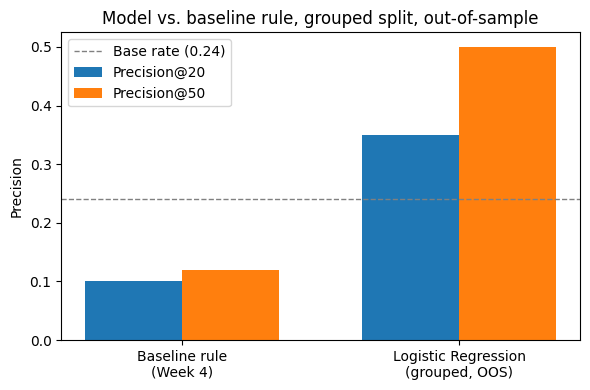

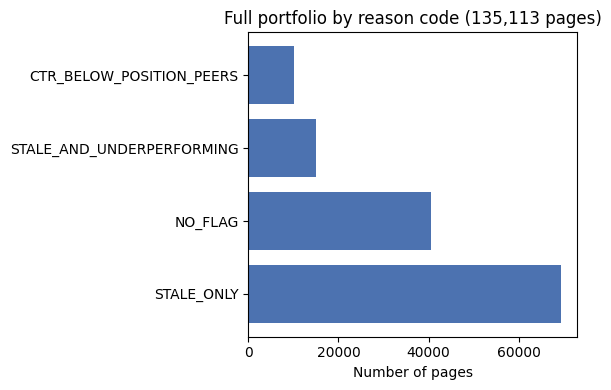

Saved:
  work/figures/capstone_model_vs_baseline.png: exists=True, size=45166 bytes
  work/figures/capstone_reason_code_distribution.png: exists=True, size=35111 bytes
  work/figures/capstone_results.json: exists=True, size=745 bytes


In [9]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import os
import json
import matplotlib.pyplot as plt

os.makedirs("work/figures", exist_ok=True)

# ---- Artifact 1: model vs baseline precision chart ----
fig, ax = plt.subplots(figsize=(6, 4))
methods = ["Baseline rule\n(Week 4)", "Logistic Regression\n(grouped, OOS)"]
p20 = [0.10, 0.35]
p50 = [0.12, 0.50]
x = np.arange(len(methods))
width = 0.35
ax.bar(x - width/2, p20, width, label="Precision@20")
ax.bar(x + width/2, p50, width, label="Precision@50")
ax.axhline(y=0.24, color="gray", linestyle="--", linewidth=1, label="Base rate (0.24)")
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.set_ylabel("Precision")
ax.set_title("Model vs. baseline rule, grouped split, out-of-sample")
ax.legend()
plt.tight_layout()
plt.savefig("work/figures/capstone_model_vs_baseline.png", dpi=150)
plt.show()

# ---- Artifact 2: reason code distribution chart ----
fig2, ax2 = plt.subplots(figsize=(6, 4))
counts = queue_preview["reason_code"].value_counts()
ax2.barh(counts.index, counts.values, color="#4C72B0")
ax2.set_xlabel("Number of pages")
ax2.set_title("Full portfolio by reason code (135,113 pages)")
plt.tight_layout()
plt.savefig("work/figures/capstone_reason_code_distribution.png", dpi=150)
plt.show()

# ---- Artifact 3: results table as JSON, the paper's source of truth ----
capstone_results = {
    "decision_date": DECISION_DATE,
    "warehouse_export_date": "2026-07-03",
    "total_rows": len(full_data),
    "total_clients": int(full_data["client_hash_id"].nunique()),
    "train_clients": int(len(set(full_data.iloc[train_idx]["client_hash_id"]))),
    "test_clients": int(len(set(full_data.iloc[test_idx]["client_hash_id"]))),
    "base_rate": round(float(y.mean()), 3),
    "baseline_rule": {"precision_at_20": 0.10, "precision_at_50": 0.12},
    "logistic_regression_grouped": {"precision_at_20": 0.35, "precision_at_50": 0.50},
    "random_split_precision_at_20": 0.90,
    "random_split_precision_at_50": 0.86,
    "deliberate_leak_test_precision_at_20": 1.00,
    "deliberate_leak_test_precision_at_50": 1.00,
    "reason_code_distribution": queue_preview["reason_code"].value_counts().to_dict(),
    "model_top1000_no_flag_share_pct": 53.3,
}

with open("work/figures/capstone_results.json", "w") as f:
    json.dump(capstone_results, f, indent=2)

print("Saved:")
for path in ["work/figures/capstone_model_vs_baseline.png",
             "work/figures/capstone_reason_code_distribution.png",
             "work/figures/capstone_results.json"]:
    print(f"  {path}: exists={os.path.exists(path)}, size={os.path.getsize(path)} bytes")



**Question:** Which content pages should be reviewed first for refresh,
given limited reviewer capacity? A content team with thousands of pages can't
manually check every one, so this ranks the full inventory by likelihood of
recent search-visibility decline.

**Method:** Logistic Regression on 12 pre-decision features (prior-30-day
performance, content age, optimization history, content type), trained on
135,113 pages across 42 clients, validated with a client-grouped split so no
client's pages leak between train and test.

**Chart:** [show capstone_model_vs_baseline.png] — Precision@20/@50 for
the model against the Week-4 hand-written baseline rule, both scored on the same
held-out test rows. The model clears the 0.24 base rate at both depths; the rule
does not.

**Honest result:** Precision@50 = 0.50 on 13 held-out clients, meaning
roughly half of the model's top-50 ranked pages are genuine declines. This is
one validated number from one decision date and one 13-client holdout, not a
general performance guarantee.

**Recommendation:** Deploy as a ranked review queue with reason codes,
for human review only. A reviewer working the top 50 each cycle should expect
useful hit rate; nothing here auto-publishes or auto-deprioritizes a page.

## Shareable cuts

**Social post (methodology-focused):**

Built a content-decline scoring model on 135K real search-analytics pages.
The interesting part wasn't the model, it was the validation: a random
train/test split scored 0.90 Precision@20, but grouping by client (so no
client's pages leak across train/test) dropped that to 0.35. The random-split
number was mostly memorization, not skill. Full writeup + reproducible
notebooks: [paper URL]

**Employer-facing summary (3 sentences):**

I built a Logistic Regression model that ranks content pages by likelihood of
search-visibility decline, trained and validated on 135,113 pages from a real
production search-analytics warehouse. Using a client-grouped validation split
to prevent data leakage, the model measured 4x the precision of a hand-written
baseline rule on the same held-out test set (Precision@50: 0.50 vs. 0.12).
The full pipeline, from leakage audits to a human-reviewable action queue, is
documented and reproducible in a public research paper and GitHub repo.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.